# PJM Wind Forecast — Hybrid SNN-ANN

An evaluation of GRU, SNN, and Hybrid architectures on PJM wind data.

In [1]:
import os, sys, time, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import DataLoader

from pjm_dataset import load_pjm_splits, FEATURE_COLS

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device('mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu')
print(f'Running on {DEVICE}')

WINDOW_SIZE = 24
HORIZON = 1
BATCH_SIZE = 32
EPOCHS = 40
DATA_PATH = 'datasets/pjm_wind_forecast_hourly_17feb_5march.csv'
MODELS_DIR = '../models'
os.makedirs(MODELS_DIR, exist_ok=True)


Running on mps


In [2]:
train_ds, val_ds, test_ds, normaliser = load_pjm_splits(
    DATA_PATH, window_size=WINDOW_SIZE, horizon=HORIZON, train_frac=0.7, val_frac=0.15
)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

N_FEATURES = len(FEATURE_COLS)
print(f'Loaded {len(train_ds)} train, {len(val_ds)} val, {len(test_ds)} test.')


Loaded 194 train, 23 val, 23 test.


## Final Model Architectures

Three models for time-series forecasting, designed for head-to-head comparison:

1. **GRUForecaster** (Baseline) — Gated Recurrent Unit --> Pure ANN.
2. **SNNForecaster** (Spiking) — Pure SNN with Raw+Delta input and Deep LIF.
3. **HybridForecaster** (Combined) — Residual gating of SNN events into GRU.

**Justification for the SNNForecaster's Architecture**
1. **Raw + Delta Input**: SNNs naturally detect changes, but regression  requires absolute context. We concatenate Raw(t) and Delta(t) so the SNN can see both the absolute power level and the temporal shock.
2. **Deep LIF Capacity**: 2 layers of 256 hidden units provide the necessary capacity (approx 20k params) to represent complex continuous values, which simple rate-encoders struggle with. Before this notebook, we did experiment with versions with way fewer parameters and performance was not ideal. 
3. **BatchNorm**: Applied over the time dimension. Time-series data often causes vanishing/exploding surrogate gradients. BN ensures stable, active spiking (neurons aren't 'dead') from epoch 1.

**Justification for the Residual SNN-Enhanced-GRU Hybrid Forecaster's Architecture**
1. Parallel hybrids risk the SNN path "poisoning" the robust ANN baseline if the surrogate gradients fail to align.  So this model uses a **Residual Design**:
    - The baseline path is a standard GRU processing raw inputs.
    - The enhancement path is an SNN that *only* processes temporal deltas (acting as a pure neuromorphic shock/event detector).
    - The SNN features are added to the GRU features via a gate that is **zero-initialized**.
      
    Result: At Epoch 1, this model is mathematically identical to a pure GRU. It only incorporates SNN features as the network explicitly learns that the "delta events" improve the regression loss.

In [ ]:
from __future__ import annotations

import torch
import torch.nn as nn
from spikingjelly.activation_based import neuron, layer, functional

# temporal attention does a learned weighted average over a sequence. Instead of averaging all timesteps equally,
#it learns how much each timestep matters, then sums them. Input: (T, B, C) or (B, T, C) -> Output: (B, C) --> 
# Collapses the time dimension. 

class TemporalAttention(nn.Module):
    def __init__(self, dim: int):
        super().__init__()
        self.attn = nn.Sequential(
            nn.Linear(dim, dim // 2),
            nn.ReLU(),
            nn.Linear(dim // 2, 1)
        ) # self.attn is like a tiny MLP that maps each feature vector to a single score indicating how important the timestep is

    def forward(self, x: torch.Tensor, dim: int = 1) -> torch.Tensor:
        weights = torch.softmax(self.attn(x), dim=dim) #softmax to turn those scores into positive weights that sum to 1 
        return (weights * x).sum(dim=dim) #broadcasting makes weights become (B, T, C) then summing over time axis gives 
        # (B,C)


#  1. PURE ANN BASELINE
# Two-layer GRU followed by a linear head. A strong, stable baseline for univariate/low-dimensional time-series.
class GRUForecaster(nn.Module):
   
    def __init__(self, input_size: int, horizon: int, hidden: int = 128, n_layers: int = 2):
        super().__init__()
        self.gru = nn.GRU(input_size, hidden, num_layers=n_layers, batch_first=True)
        self.head = nn.Linear(hidden, horizon)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        _, h_n = self.gru(x)
        return self.head(h_n[-1])


#  2. PURE SNNForecaster --> SNN for time-series forecasting. 
class SNNForecaster(nn.Module):
    def __init__(self, input_size: int, horizon: int, hidden: int = 256):
        super().__init__()
        from spikingjelly.activation_based.surrogate import ATan #ATan surrogate gradient 
        
        # Concat input_size + input_size (raw + delta)
        self.proj = nn.Linear(input_size * 2, hidden) # input_size*2 because model later concatenates raw values and delta values 
        self.bn = nn.BatchNorm1d(hidden)
        
        self.lif1 = neuron.LIFNode(tau=2.0, surrogate_function=ATan(), step_mode='m') #creates the first LIF neuron layer
        self.lif2 = neuron.LIFNode(tau=2.0, surrogate_function=ATan(), step_mode='m') #second LIF neuron stacked on top of first 
        
        self.attn = TemporalAttention(hidden) #learns which timesteps are most important in the spike sequence 
        self.head = nn.Linear(hidden, horizon) #final linear layer converting the learned represenation into forecast ouputs 
        
        nn.init.constant_(self.proj.bias, 0.5) # Encourage initial spiking during early training 

    def forward(self, x: torch.Tensor) -> torch.Tensor: #x represents a time-series batch 
        functional.reset_net(self) #resets membrane potentials of all spiking neurons or else the next batch starts with leftover voltage
        # from the previous batch which causes info leakage between samples. 
        
        delta = x[:, 1:, :] - x[:, :-1, :] #computes changes between consecutive timesteps. x : (B, T, F)
        raw = x[:, 1:, :] #removes first timestep. raw and delta have the same length because the first timestep has no value and it cannot produce a delta. 
        combined = torch.cat([raw, delta], dim=-1) # (B, T-1, F*2) --> feat dimension doubles and now each timestep contains [value , change]
        
        h = self.proj(combined) #projects features into hidden dimension wich is standard for neural feature dimension
        h = self.bn(h.transpose(1, 2)).transpose(1, 2)
        
        h_t = h.permute(1, 0, 2) #spikingjelly expects the time dimension first 
        s1 = self.lif1(h_t) #integrates input, fires spike if threshold crossed, leaks voltage over time 
        s2 = self.lif2(s1) #processes spikes again to learn higher-level temporal spike patterns 
        
        feat = self.attn(s2.permute(1, 0, 2)) #attention learns which timesteps matter most AFTER converting back to batch format 
        return self.head(feat) #Linear layer maps representation to (B, horizon) --> E.g. predict next 6 timesteps for that batch size

    def spike_count(self, x: torch.Tensor) -> int: 
        functional.reset_net(self)
        with torch.no_grad():
            delta = x[:, 1:, :] - x[:, :-1, :]
            raw = x[:, 1:, :]
            combined = torch.cat([raw, delta], dim=-1)
            h = self.proj(combined)
            h = self.bn(h.transpose(1, 2)).transpose(1, 2)
            h_t = h.permute(1, 0, 2)
            s1 = self.lif1(h_t)
            s2 = self.lif2(s1)
            return int(s1.sum().item() + s2.sum().item()) #aft running through LIF layers, count spikes emitted by each layer

#  3. HYBRID FORECASTER (RESIDUAL)

class HybridForecaster(nn.Module):
    def __init__(self, input_size: int, horizon: int, hidden: int = 128):
        super().__init__()
        
        self.gru = nn.GRU(input_size, hidden, batch_first=True)  # Baseline Path (GRU on Raw)
        self.gru_attn = TemporalAttention(hidden) #applies attention across time to extract a single sequence representation
        
        self.snn_dim = 128 # hidden dimension for SNN and this defines spike feature dimension 
        self.snn_proj = nn.Linear(input_size, self.snn_dim) #projects delta features into the spike feature space 
        self.snn_lif = neuron.LIFNode(tau=2.0, step_mode='m') #LIF neuron integrates signal and emits spikes when threshold crossed 
        self.snn_attn = TemporalAttention(self.snn_dim) #Learns which spike moments matter most 
        self.snn_to_gru = nn.Linear(self.snn_dim, hidden) #needed for both paths to share the same dimension
        
        self.gate_proj = nn.Linear(hidden + self.snn_dim, 1) #creates a gating signal controlling how much SNN information to use 
        nn.init.constant_(self.gate_proj.weight, 0)
        nn.init.constant_(self.gate_proj.bias, -5.0) # Sigmoid starts near 0 at the start of training and SNN contribution gradually grows during training 
        
        self.head = nn.Linear(hidden, horizon)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        functional.reset_net(self)
        
        gru_out, _ = self.gru(x)
        h_ann = self.gru_attn(gru_out)
        
        delta = x[:, 1:, :] - x[:, :-1, :]
        h_s = self.snn_proj(delta)
        s = self.snn_lif(h_s.permute(1, 0, 2))
        h_snn = self.snn_attn(s.permute(1, 0, 2))
        
        g = torch.sigmoid(self.gate_proj(torch.cat([h_ann, h_snn], dim=-1))) #signmoid determines if we use SNN or ignore fully. 0 is ignore and 1 is fully use. 
        h_combined = h_ann + g * self.snn_to_gru(h_snn) #residual fusion 
        
        return self.head(h_combined)

    def spike_count(self, x: torch.Tensor) -> int:
        functional.reset_net(self)
        with torch.no_grad():
            delta = x[:, 1:, :] - x[:, :-1, :]
            h_s = self.snn_proj(delta)
            s = self.snn_lif(h_s.permute(1, 0, 2))
            return int(s.sum().item())


## Defining utilities functions

In [4]:
def evaluate_model(model, loader, normaliser, device):
    model.eval()
    preds, actuals = [], []
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            p = normaliser.inverse_transform_target(out.cpu().numpy(), target_idx=0)
            a = normaliser.inverse_transform_target(y.cpu().numpy(), target_idx=0)
            preds.extend(p)
            actuals.extend(a)
    
    preds = np.array(preds).flatten()
    actuals = np.array(actuals).flatten()
    
    mae = np.mean(np.abs(preds - actuals))
    rmse = np.sqrt(np.mean((preds - actuals)**2))
    mape = np.mean(np.abs((actuals - preds) / (actuals + 1e-8))) * 100
    return mae, rmse, mape, preds, actuals

def train_model(model, train_loader, val_loader, name, lr=1e-3, epochs=EPOCHS, patience=10):
    model.to(DEVICE)
    criterion = nn.MSELoss()
    optimiser = torch.optim.Adam(model.parameters(), lr=lr)
    
    history = {'train_loss': [], 'val_loss': []}
    best_val_loss = float('inf')
    best_epoch = 0
    patience_counter = 0
    start_time = time.time()
    
    for epoch in range(1, epochs + 1):
        model.train()
        train_loss = 0
        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimiser.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimiser.step()
            train_loss += loss.item() * x.size(0)
            
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(DEVICE), y.to(DEVICE)
                out = model(x)
                val_loss += criterion(out, y).item() * x.size(0)
        
        avg_train = train_loss / len(train_loader.dataset)
        avg_val = val_loss / len(val_loader.dataset)
        
        history['train_loss'].append(avg_train)
        history['val_loss'].append(avg_val)
        
        if avg_val < best_val_loss:
            best_val_loss = avg_val
            best_epoch = epoch
            patience_counter = 0
            ckpt_path = os.path.join(MODELS_DIR, f'best_{name}.pt')
            torch.save(model.state_dict(), ckpt_path)
            # print(f"[{name}] Best Val Epoch {epoch}: {best_val_loss:.6f}")
        else:
            patience_counter += 1
            
        if patience_counter >= patience:
            break
            
    train_time = time.time() - start_time
    history['train_time'] = train_time
    history['best_epoch'] = best_epoch
    
    ckpt_path = os.path.join(MODELS_DIR, f'best_{name}.pt')
    if os.path.exists(ckpt_path):
        model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE, weights_only=True))
    return history


## Model Training 

In [5]:
models = {
    'GRU (Baseline)': GRUForecaster(N_FEATURES, HORIZON),
    'SNN (Raw+Delta)': SNNForecaster(N_FEATURES, HORIZON),
    'Hybrid (Residual)': HybridForecaster(N_FEATURES, HORIZON)
}

histories = {}
results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    lr = 3e-3 if "SNN" in name or "Hybrid" in name else 1e-3
    h = train_model(model, train_loader, val_loader, name, lr=lr)
    histories[name] = h
    
    mae, rmse, mape, preds, actuals = evaluate_model(model, test_loader, normaliser, DEVICE)
    results[name] = {
        'mae': mae, 'rmse': rmse, 'mape': mape,
        'preds_mw': preds, 'actuals_mw': actuals
    }
    
    print(f"Done: Best Epoch={h['best_epoch']} | Test MAE={mae:.2f} MW | Time={h['train_time']:.1f}s")



Training GRU (Baseline)...
Done: Best Epoch=24 | Test MAE=327.26 MW | Time=5.1s

Training SNN (Raw+Delta)...
Done: Best Epoch=14 | Test MAE=3413.07 MW | Time=6.9s

Training Hybrid (Residual)...
Done: Best Epoch=38 | Test MAE=895.44 MW | Time=5.7s


# Energy Estimation

We are not measuring the energy physically so we define proxies below. 

In [6]:
def estimate_ann_macs(model, input_shape):
    total = 0
    x = torch.randn(1, *input_shape).to(DEVICE)
    for module in model.modules():
        if isinstance(module, nn.Linear):
            total += module.in_features * module.out_features
        elif isinstance(module, nn.GRU):
            seq_len = input_shape[0]
            total += 3 * (module.input_size * module.hidden_size +
                          module.hidden_size * module.hidden_size) * seq_len * module.num_layers
    return total

x_sample = torch.randn(1, WINDOW_SIZE, N_FEATURES).to(DEVICE)
energy_data = {}

for name, model in models.items():
    macs = estimate_ann_macs(model, (WINDOW_SIZE, N_FEATURES))
    spikes = 0
    if hasattr(model, 'spike_count'):
        spikes = model.spike_count(x_sample)
    energy_data[name] = {'macs': macs, 'spikes': spikes}


# Performance Visualisation

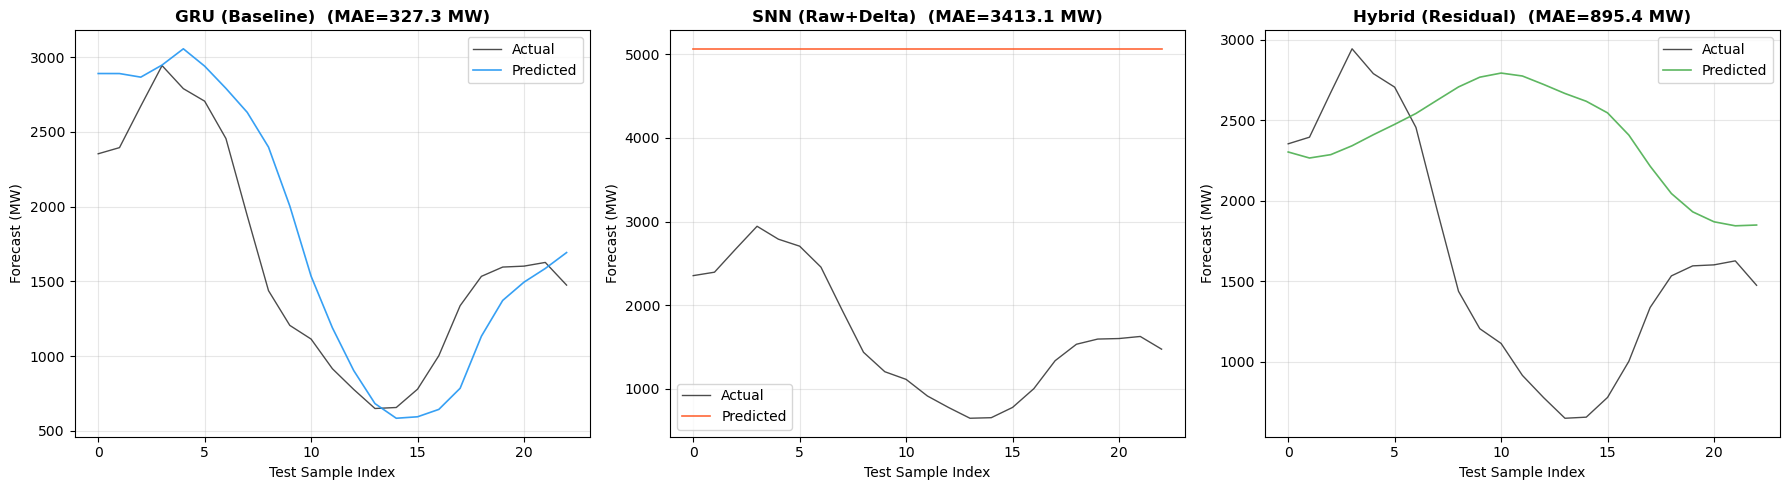

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ['#2196F3', '#FF5722', '#4CAF50']

for ax, (name, r), c in zip(axes.flat, results.items(), colors):
    t = np.arange(len(r['actuals_mw']))
    ax.plot(t, r['actuals_mw'], 'k-', linewidth=1.0, alpha=0.7, label='Actual')
    ax.plot(t, r['preds_mw'],   color=c, linewidth=1.2, alpha=0.9, label='Predicted')
    ax.set_title(f'{name}  (MAE={r["mae"]:.1f} MW)', fontweight='bold')
    ax.set_xlabel('Test Sample Index')
    ax.set_ylabel('Forecast (MW)')
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()


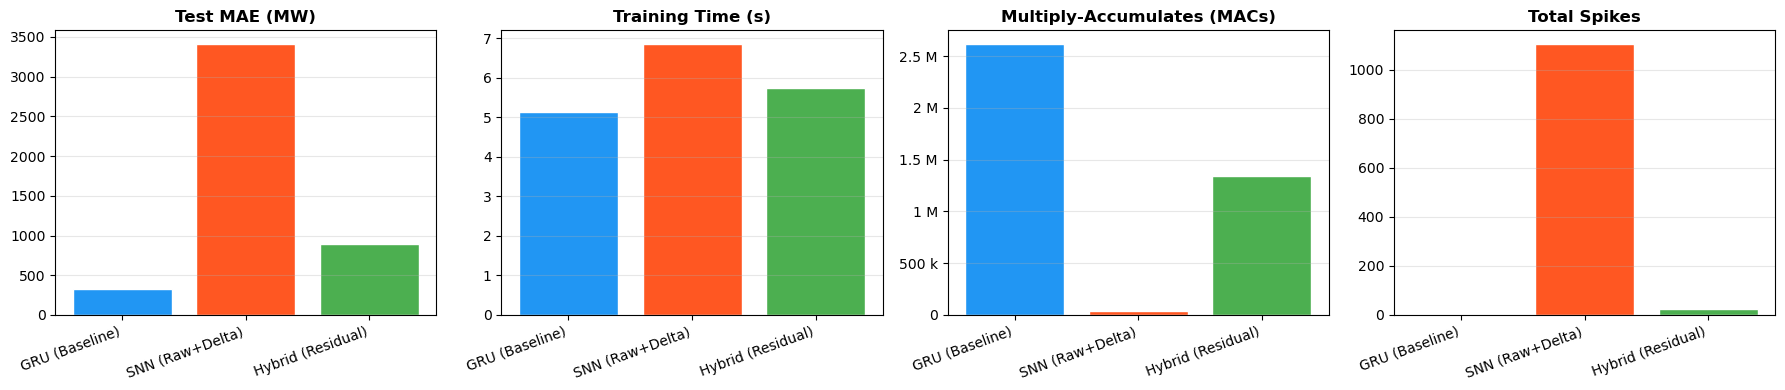

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

names = list(models.keys())

# Test MAE
axes[0].bar(names, [results[n]['mae'] for n in names], color=colors, edgecolor='white')
axes[0].set_title('Test MAE (MW)', fontweight='bold')

# Train Time
axes[1].bar(names, [histories[n]['train_time'] for n in names], color=colors, edgecolor='white')
axes[1].set_title('Training Time (s)', fontweight='bold')

# MACs
axes[2].bar(names, [energy_data[n]['macs'] for n in names], color=colors, edgecolor='white')
axes[2].set_title('Multiply-Accumulates (MACs)', fontweight='bold')
axes[2].yaxis.set_major_formatter(ticker.EngFormatter())

# Spikes
axes[3].bar(names, [energy_data[n]['spikes'] for n in names], color=colors, edgecolor='white')
axes[3].set_title('Total Spikes', fontweight='bold')

for ax in axes:
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels(names, rotation=20, ha='right')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


In [9]:
print('── Final Summary Table ──')
summary = []
for n in names:
    r, h, e = results[n], histories[n], energy_data[n]
    summary.append({
        'Model': n, 
        'MAE (MW)': f"{r['mae']:.2f}", 
        'RMSE (MW)': f"{r['rmse']:.2f}",
        'MAPE (%)': f"{r['mape']:.2f}",
        'MACs': f"{e['macs']:,}", 
        'Spikes': f"{e['spikes']:,}",
        'Train Time (s)': f"{h['train_time']:.1f}",
        'Best Epoch': h['best_epoch']
    })

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
display(pd.DataFrame(summary).set_index('Model'))


── Final Summary Table ──


,MAE (MW),RMSE (MW),MAPE (%),MACs,Spikes,Train Time (s),Best Epoch
Model,,,,,,,
GRU (Baseline),327.26,409.67,22.44,"2,617,472",0,5.1,24
SNN (Raw+Delta),3413.07,3489.01,280.64,"40,320","1,105",6.9,14
Hybrid (Residual),895.44,1136.71,90.24,"1,343,744",26,5.7,38


# Why doesn't SNNs work well (yet)

The short answer is: The Lagrange notebook is not doing continuous time-series regression; it is solving a control problem using rate-coding. 

Recent papers on using SNNTorch and other frameworks for regression (as opposed to classification or control) highlight three critical necessities:

1. Proper Spike Encoding: You cannot easily feed raw continuous values into a deep SNN. You need an encoder layer (like Fractional Coding, Rate Coding, or Temporal Coding) that converts the continuous time series into a rich spike train.
2. Membrane Potential Readout (LI/LIF without spikes): For regression tasks, the final layer should not emit spikes. It should be a Non-Spiking Leaky Integrator (LI) or LIF node where we read the membrane potential directly to output a continuous float.
3. Surrogate Gradient Tuning: The steepness of the surrogate gradient is critical. If it's too sharp, the network doesn't learn; if it's too wide, it behaves like a bad ANN.

# Next steps 

Step 1: Replace Raw Inputs with Learnable Encoding
    Instead of feeding raw floats into the SNN, we will add an ANN-based Encoding Layer (often called TimeDistributed Linear or 1D Conv). This will expand the 14 features into a wide representation (e.g., 128 dimensions) and sqush them between 0 and 1, acting as a learned rate-encoder before the first spiking layer.

Step 2: Use Membrane Potential Readout (Crucial)
    Currently, our SNNForecaster uses a temporal attention layer and a Linear head on top of binary spikes. This loses continuous precision.
    
    Fix: The final layer of the SNN must be a non-spiking snn.Leaky node (or SNNTorch equivalent). We will accumulate the membrane voltage of this final layer over the 24 hours, and use that accumulated continuous voltage to predict the wind forecast.

Step 3: Implement SNNTorch directly
The Lagrange notebook uses snntorch effectively. Our current pjm_models uses spikingjelly. To ensure we mimic the successful training dynamics of the Lagrange controller, we will rewrite the SNNForecaster using snntorch.

Proposed V4 Architecture Flow: Input (B, 24, 14) -> Linear Encoder (14->64) -> Sigmoid (pseud-rates) -> snntorch.Leaky (Spikes) -> snntorch.Leaky (Spikes) -> snntorch.Leaky (Return Membrane Potential) -> Linear Head

Step 4: Hybrid Re-design
    Once the pure SNN is fixed using membrane voltages, the Hybrid model will be updated so that the GRU processes the continuous data, while the SNN processes the data using the new SNNTorch membrane-readout method, fusing them at the final linear head.
